# Improving the Baselines

`eda_and_baselines.ipynb` builds six baseline models and shows (Part 2 there) that a proper
**scaffold split** — grouping compounds so no chemotype leaks between train and test — drops every
model's ROC-AUC relative to the looser `cid`-grouped split. This notebook picks up from there and
improves each baseline **one at a time**, always evaluated on that same scaffold split, so every
number here is comparable to that notebook's Part 2 and to each other.

For each model, three stages are attempted in order, keeping whatever helps (judged by grouped
cross-validation or a held-out validation split — **never the test set** — so the improvement
choices themselves aren't peeking at the number being reported):

1. **Hyperparameter tuning** — grouped CV search (`GroupKFold` on scaffold) over the model's key knobs.
2. **Feature / representation engineering** — a change specific to that model's inputs.
3. **Calibration + threshold tuning** — Platt scaling fit on a held-out validation split, plus
   picking the decision threshold that maximizes balanced accuracy on that same validation split
   (rather than the default 0.5).

Order: LogisticRegression → RandomForest → XGBoost → TabPFN → CheMeleon → DeepTox-style DNN,
matching `eda_and_baselines.ipynb`.

## 1. Setup and load data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

REPO_ROOT = "/nethome/akarimi/ak_repos_github/cytotoxicity-dataset-collection"
df = pd.read_csv(f"{REPO_ROOT}/data/combined/combined_cytotoxicity_classification.csv")
labeled = df.dropna(subset=["cytotoxic_label", "canonical_smiles"]).copy()
labeled["cytotoxic_label"] = labeled["cytotoxic_label"].astype(int)
print(f"Rows usable for modeling: {len(labeled)} / {len(df)}")

Rows usable for modeling: 14105 / 15476


## 2. Featurization: Morgan fingerprints + physicochemical descriptors

Same two feature sources as `eda_and_baselines.ipynb`: ECFP4-style Morgan fingerprints
(radius=2, 2048 bits) as the default representation for every fingerprint-based model, and a
10-descriptor physicochemical set (MW, LogP, TPSA, ...) used as an optional add-on in the
feature-engineering stage below.

In [2]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, MACCSkeys
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

FP_RADIUS, FP_BITS = 2, 2048
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_BITS)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(fp_gen.GetFingerprint(mol))

unique_smiles = labeled["canonical_smiles"].unique()
fp_cache = {s: smiles_to_fp(s) for s in unique_smiles}
n_failed = sum(v is None for v in fp_cache.values())
print(f"Featurized {len(unique_smiles) - n_failed}/{len(unique_smiles)} unique structures ({n_failed} failed)")

labeled["_fp"] = labeled["canonical_smiles"].map(fp_cache)
model_df = labeled.dropna(subset=["_fp"]).reset_index(drop=True)
X = np.stack(model_df["_fp"].values)
y = model_df["cytotoxic_label"].values
print(f"Modeling rows: {len(model_df)}, feature matrix: {X.shape}")

Featurized 8621/8621 unique structures (0 failed)
Modeling rows: 14105, feature matrix: (14105, 2048)


In [3]:
DESCRIPTOR_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "RingCount": Descriptors.RingCount,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumHeteroatoms": Descriptors.NumHeteroatoms,
}

def smiles_to_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return np.array([f(mol) for f in DESCRIPTOR_FUNCS.values()], dtype=np.float32)

def smiles_to_maccs(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return np.array(MACCSkeys.GenMACCSKeys(mol))

desc_cache = {s: smiles_to_descriptors(s) for s in unique_smiles}
maccs_cache = {s: smiles_to_maccs(s) for s in unique_smiles}
print(f"Descriptors: {len(desc_cache)} cached, {len(DESCRIPTOR_FUNCS)}-dim. "
      f"MACCS keys: {len(maccs_cache)} cached, {len(next(iter(maccs_cache.values())))}-dim.")

Descriptors: 8621 cached, 10-dim. MACCS keys: 8621 cached, 167-dim.


## 3. Scaffold split

Same greedy, size-aware scaffold allocator as `eda_and_baselines.ipynb` Part 2 (plain
`StratifiedGroupKFold` degenerates badly here — a handful of scaffolds contain hundreds of
compounds, so a k-fold splitter built for even group sizes puts almost everything in one fold).
Same seed and `frac_train`, so this reproduces that notebook's exact test set.

In [4]:
def greedy_scaffold_split(scaffold_values, frac_train=0.8, seed=42):
    scaffold_to_indices = {}
    for idx, scaf in enumerate(scaffold_values):
        scaffold_to_indices.setdefault(scaf, []).append(idx)
    scaffold_sets = list(scaffold_to_indices.values())

    rng = np.random.default_rng(seed)
    order = rng.permutation(len(scaffold_sets))
    scaffold_sets = [scaffold_sets[i] for i in order]
    scaffold_sets.sort(key=len, reverse=True)

    n_total = len(scaffold_values)
    train_cutoff = frac_train * n_total

    train_idx, test_idx = [], []
    for s in scaffold_sets:
        if len(train_idx) + len(s) <= train_cutoff:
            train_idx.extend(s)
        else:
            test_idx.extend(s)
    return np.array(sorted(train_idx)), np.array(sorted(test_idx))

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    s = Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))
    return s if s else "(acyclic)"

scaffold_cache = {s: get_scaffold(s) for s in unique_smiles}
model_df["_scaffold"] = model_df["canonical_smiles"].map(scaffold_cache)

train_idx, test_idx = greedy_scaffold_split(model_df["_scaffold"].values, frac_train=0.8, seed=42)
meta_train, meta_test = model_df.iloc[train_idx], model_df.iloc[test_idx]

assert set(meta_train["_scaffold"]) & set(meta_test["_scaffold"]) == set(), "scaffold leakage!"
print(f"Train: {len(meta_train)} rows ({meta_train['cytotoxic_label'].mean():.1%} active), "
      f"{meta_train['_scaffold'].nunique()} unique scaffolds")
print(f"Test:  {len(meta_test)} rows ({meta_test['cytotoxic_label'].mean():.1%} active), "
      f"{meta_test['_scaffold'].nunique()} unique scaffolds")

# A further val split carved out of train only (also scaffold-grouped) -- reserved for
# calibration, threshold tuning, and early stopping. Never touched by hyperparameter search
# or by the final test-set evaluation.
fit_idx, val_idx = greedy_scaffold_split(meta_train["_scaffold"].values, frac_train=0.9, seed=42)
meta_fit, meta_val = meta_train.iloc[fit_idx], meta_train.iloc[val_idx]
print(f"Fit:   {len(meta_fit)} rows ({meta_fit['cytotoxic_label'].mean():.1%} active)")
print(f"Val:   {len(meta_val)} rows ({meta_val['cytotoxic_label'].mean():.1%} active)")

Train: 11284 rows (37.6% active), 567 unique scaffolds
Test:  2821 rows (51.5% active), 1804 unique scaffolds
Fit:   10155 rows (36.6% active)
Val:   1129 rows (46.9% active)


## 4. Shared helpers

Every model below is built the same way: pull features for a `meta_*` subset by its original
row position (fingerprints and descriptors are pre-computed and aligned to `model_df`'s index,
so any `meta` slice can look itself up), tune hyperparameters via grouped CV on train, optionally
swap in a different feature set, then calibrate + pick a threshold on `meta_val` before the one
evaluation on `meta_test`.

In [5]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score
from scipy.stats import loguniform, uniform, randint

CV_SPLITS = 3

def get_fp(meta):
    return X[meta.index.values]

def get_y(meta):
    return meta["cytotoxic_label"].values

def get_desc_raw(meta):
    return np.stack([desc_cache[s] for s in meta["canonical_smiles"]])

def get_maccs(meta):
    return np.stack([maccs_cache[s] for s in meta["canonical_smiles"]])

def fp_desc_features(fit_meta, target_meta, scaler=None):
    """Fingerprint + scaled descriptors. Fit the scaler on `fit_meta`, apply to `target_meta`."""
    if scaler is None:
        scaler = StandardScaler().fit(get_desc_raw(fit_meta))
    desc = scaler.transform(get_desc_raw(target_meta))
    return np.concatenate([get_fp(target_meta), desc], axis=1).astype(np.float32), scaler

def cv_roc_auc(estimator, meta, n_splits=CV_SPLITS, feature_fn=get_fp):
    """Grouped-by-scaffold CV ROC-AUC, refitting the feature transform inside each fold."""
    groups = meta["_scaffold"].values
    gkf = GroupKFold(n_splits=n_splits)
    scores = []
    for tr, va in gkf.split(meta, get_y(meta), groups):
        meta_tr, meta_va = meta.iloc[tr], meta.iloc[va]
        if feature_fn is get_fp:
            Xtr, Xva = get_fp(meta_tr), get_fp(meta_va)
        else:
            Xtr, scaler = feature_fn(meta_tr, meta_tr)
            Xva, _ = feature_fn(meta_tr, meta_va, scaler=scaler)
        est = clone(estimator).fit(Xtr, get_y(meta_tr))
        scores.append(roc_auc_score(get_y(meta_va), est.predict_proba(Xva)[:, 1]))
    return float(np.mean(scores)), float(np.std(scores))

def tune_threshold(y_true, y_prob, n_steps=81):
    thresholds = np.linspace(0.05, 0.95, n_steps)
    accs = [balanced_accuracy_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    best_i = int(np.argmax(accs))
    return float(thresholds[best_i]), float(accs[best_i])

def platt_calibrate(fit_prob, fit_y, apply_prob):
    eps = 1e-6
    def logit(p):
        p = np.clip(p, eps, 1 - eps)
        return np.log(p / (1 - p)).reshape(-1, 1)
    platt = LogisticRegression()
    platt.fit(logit(fit_prob), fit_y)
    return platt.predict_proba(logit(apply_prob))[:, 1]

improve_results = []

def record(model, stage, y_true, y_prob, meta, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    row = {
        "model": model, "stage": stage, "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }
    for src in meta["source"].unique():
        mask = (meta["source"] == src).values
        if mask.sum() > 0 and len(np.unique(y_true[mask])) > 1:
            row[f"roc_auc_{src}"] = roc_auc_score(y_true[mask], y_prob[mask])
    improve_results.append(row)
    print(f"[{model:19s} | {stage:14s}] ROC-AUC={row['roc_auc']:.3f}  PR-AUC={row['pr_auc']:.3f}  "
          f"balanced_acc={row['balanced_accuracy']:.3f} (thr={threshold:.2f})  F1={row['f1']:.3f}")
    return row

y_test = get_y(meta_test)
y_val = get_y(meta_val)
y_fit = get_y(meta_fit)
y_train = get_y(meta_train)
train_groups = meta_train["_scaffold"].values

In [6]:
def make_features(feature_kind, fit_meta, target_meta, scaler=None):
    if feature_kind == "fp":
        return get_fp(target_meta), None
    elif feature_kind == "fp_desc":
        return fp_desc_features(fit_meta, target_meta, scaler=scaler)
    else:
        raise ValueError(feature_kind)

def summarize_model(model_name):
    sub = pd.DataFrame([r for r in improve_results if r["model"] == model_name])
    print(sub[["stage", "roc_auc", "pr_auc", "balanced_accuracy", "f1", "threshold"]].to_string(index=False))
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(sub["stage"], sub["roc_auc"], color="#4C78A8")
    ax.axhline(sub["roc_auc"].iloc[0], color="gray", ls=":", lw=1, label="baseline")
    ax.set_ylabel("ROC-AUC")
    ax.set_ylim(min(0.5, sub["roc_auc"].min() - 0.05), max(sub["roc_auc"].max() + 0.05, 0.7))
    ax.set_title(f"{model_name}: ROC-AUC by stage")
    ax.legend()
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()
    return sub

# Part A: LogisticRegression

### A.1 Baseline

Same config as `eda_and_baselines.ipynb`: `class_weight="balanced"`, default `C=1.0`, fp-only features.

In [7]:
logreg_baseline = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
logreg_baseline.fit(get_fp(meta_train), y_train)
prob = logreg_baseline.predict_proba(get_fp(meta_test))[:, 1]
_ = record("LogisticRegression", "baseline", y_test, prob, meta_test)

[LogisticRegression  | baseline      ] ROC-AUC=0.666  PR-AUC=0.674  balanced_acc=0.617 (thr=0.50)  F1=0.611


### A.2 Hyperparameter tuning

`RandomizedSearchCV` over `C` and the L1/L2 penalty, scored by ROC-AUC under `GroupKFold`
(grouped by scaffold, so no scaffold leaks between the search's own train/validation folds).

In [9]:
logreg_param_dist = {
    "C": loguniform(1e-3, 1e2),
    "penalty": ["l1", "l2"],
}
logreg_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear", random_state=42),
    logreg_param_dist, n_iter=12, scoring="roc_auc",
    cv=GroupKFold(n_splits=CV_SPLITS), n_jobs=-1, random_state=42,
)
logreg_search.fit(get_fp(meta_train), y_train, groups=train_groups)
print(f"Best params: {logreg_search.best_params_}  (CV ROC-AUC={logreg_search.best_score_:.3f})")

logreg_tuned = logreg_search.best_estimator_  # already refit on full train
prob = logreg_tuned.predict_proba(get_fp(meta_test))[:, 1]
_ = record("LogisticRegression", "+tuning", y_test, prob, meta_test)
logreg_best_params = logreg_search.best_params_

Best params: {'C': np.float64(0.04661686413912769), 'penalty': 'l2'}  (CV ROC-AUC=0.661)
[LogisticRegression  | +tuning       ] ROC-AUC=0.718  PR-AUC=0.715  balanced_acc=0.662 (thr=0.50)  F1=0.670


### A.3 Feature engineering: fingerprint-only vs. fingerprint + descriptors

Compares the two feature sets by grouped CV (never the test set) using the tuned hyperparameters,
then refits the winner on the full training set.

In [10]:
logreg_est_for_features = LogisticRegression(
    max_iter=2000, class_weight="balanced", solver="liblinear", random_state=42, **logreg_best_params,
)
cv_fp, _ = cv_roc_auc(logreg_est_for_features, meta_train, feature_fn=get_fp)
cv_fp_desc, _ = cv_roc_auc(logreg_est_for_features, meta_train, feature_fn=fp_desc_features)
print(f"CV ROC-AUC: fp-only={cv_fp:.3f}  fp+descriptors={cv_fp_desc:.3f}")

logreg_feature_kind = "fp_desc" if cv_fp_desc > cv_fp else "fp"
print(f"Winner: {logreg_feature_kind}")

Xtr, logreg_scaler = make_features(logreg_feature_kind, meta_train, meta_train)
Xte, _ = make_features(logreg_feature_kind, meta_train, meta_test, scaler=logreg_scaler)
logreg_final = clone(logreg_est_for_features).fit(Xtr, y_train)
prob = logreg_final.predict_proba(Xte)[:, 1]
_ = record("LogisticRegression", "+features", y_test, prob, meta_test)

CV ROC-AUC: fp-only=0.661  fp+descriptors=0.690
Winner: fp_desc
[LogisticRegression  | +features     ] ROC-AUC=0.747  PR-AUC=0.722  balanced_acc=0.676 (thr=0.50)  F1=0.712


### A.4 Calibration + threshold tuning

Refit the winning config on `meta_fit` only (holding out `meta_val`), fit a Platt (logistic-on-logit)
calibrator on `meta_val`'s predictions, apply it to test, and pick the decision threshold that
maximizes balanced accuracy on `meta_val` (never on test).

In [11]:
Xfit, logreg_scaler_fit = make_features(logreg_feature_kind, meta_fit, meta_fit)
Xval, _ = make_features(logreg_feature_kind, meta_fit, meta_val, scaler=logreg_scaler_fit)
Xtest_cal, _ = make_features(logreg_feature_kind, meta_fit, meta_test, scaler=logreg_scaler_fit)

logreg_cal_model = clone(logreg_est_for_features).fit(Xfit, y_fit)
val_prob = logreg_cal_model.predict_proba(Xval)[:, 1]
test_prob_raw = logreg_cal_model.predict_proba(Xtest_cal)[:, 1]

test_prob_cal = platt_calibrate(val_prob, y_val, test_prob_raw)
val_prob_cal = platt_calibrate(val_prob, y_val, val_prob)
logreg_best_thr, _ = tune_threshold(y_val, val_prob_cal)

_ = record("LogisticRegression", "+calibration", y_test, test_prob_cal, meta_test, threshold=logreg_best_thr)

[LogisticRegression  | +calibration  ] ROC-AUC=0.735  PR-AUC=0.709  balanced_acc=0.675 (thr=0.44)  F1=0.698


### A.5 Summary — LogisticRegression

       stage  roc_auc   pr_auc  balanced_accuracy       f1  threshold
    baseline 0.665898 0.674161           0.617052 0.611410    0.50000
     +tuning 0.717942 0.714760           0.662085 0.669900    0.50000
     +tuning 0.717942 0.714760           0.662085 0.669900    0.50000
   +features 0.746637 0.722376           0.676271 0.712425    0.50000
+calibration 0.734630 0.708875           0.674811 0.697782    0.44375


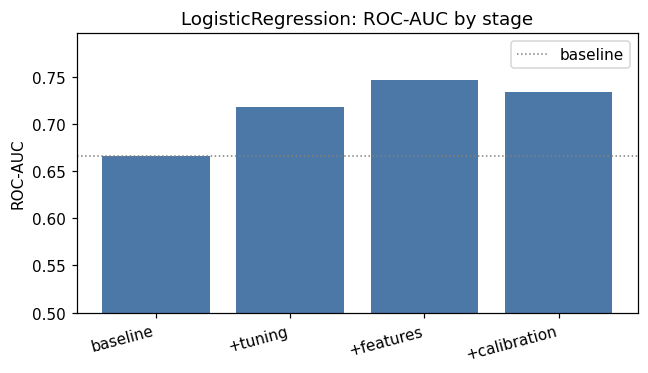

In [12]:
logreg_summary = summarize_model("LogisticRegression")

# Part B: RandomForest

### B.1 Baseline

In [13]:
rf_baseline = RandomForestClassifier(
    n_estimators=500, max_depth=None, class_weight="balanced_subsample", n_jobs=-1, random_state=42,
)
rf_baseline.fit(get_fp(meta_train), y_train)
prob = rf_baseline.predict_proba(get_fp(meta_test))[:, 1]
_ = record("RandomForest", "baseline", y_test, prob, meta_test)

[RandomForest        | baseline      ] ROC-AUC=0.727  PR-AUC=0.720  balanced_acc=0.649 (thr=0.50)  F1=0.582


### B.2 Hyperparameter tuning

In [14]:
rf_param_dist = {
    "n_estimators": randint(150, 400),
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", 0.3],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", n_jobs=-1, random_state=42),
    rf_param_dist, n_iter=10, scoring="roc_auc",
    cv=GroupKFold(n_splits=CV_SPLITS), n_jobs=1, random_state=42,
)
rf_search.fit(get_fp(meta_train), y_train, groups=train_groups)
print(f"Best params: {rf_search.best_params_}  (CV ROC-AUC={rf_search.best_score_:.3f})")

rf_tuned = rf_search.best_estimator_
prob = rf_tuned.predict_proba(get_fp(meta_test))[:, 1]
_ = record("RandomForest", "+tuning", y_test, prob, meta_test)
rf_best_params = rf_search.best_params_

Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 378}  (CV ROC-AUC=0.650)
[RandomForest        | +tuning       ] ROC-AUC=0.730  PR-AUC=0.720  balanced_acc=0.662 (thr=0.50)  F1=0.664


### B.3 Feature engineering: fingerprint-only vs. fingerprint + descriptors

In [15]:
rf_est_for_features = RandomForestClassifier(
    class_weight="balanced_subsample", n_jobs=-1, random_state=42, **rf_best_params,
)
cv_fp, _ = cv_roc_auc(rf_est_for_features, meta_train, feature_fn=get_fp)
cv_fp_desc, _ = cv_roc_auc(rf_est_for_features, meta_train, feature_fn=fp_desc_features)
print(f"CV ROC-AUC: fp-only={cv_fp:.3f}  fp+descriptors={cv_fp_desc:.3f}")

rf_feature_kind = "fp_desc" if cv_fp_desc > cv_fp else "fp"
print(f"Winner: {rf_feature_kind}")

Xtr, rf_scaler = make_features(rf_feature_kind, meta_train, meta_train)
Xte, _ = make_features(rf_feature_kind, meta_train, meta_test, scaler=rf_scaler)
rf_final = clone(rf_est_for_features).fit(Xtr, y_train)
prob = rf_final.predict_proba(Xte)[:, 1]
_ = record("RandomForest", "+features", y_test, prob, meta_test)

CV ROC-AUC: fp-only=0.650  fp+descriptors=0.718
Winner: fp_desc
[RandomForest        | +features     ] ROC-AUC=0.774  PR-AUC=0.762  balanced_acc=0.694 (thr=0.50)  F1=0.735


### B.4 Calibration + threshold tuning

RandomForest probabilities are notoriously blocky (bounded by `1/n_estimators` granularity) —
isotonic regression is the standard fix, but with a small (~1,100-row) validation set isotonic can
overfit, so this uses the same Platt approach as the other models for consistency and robustness
at this sample size.

In [16]:
Xfit, rf_scaler_fit = make_features(rf_feature_kind, meta_fit, meta_fit)
Xval, _ = make_features(rf_feature_kind, meta_fit, meta_val, scaler=rf_scaler_fit)
Xtest_cal, _ = make_features(rf_feature_kind, meta_fit, meta_test, scaler=rf_scaler_fit)

rf_cal_model = clone(rf_est_for_features).fit(Xfit, y_fit)
val_prob = rf_cal_model.predict_proba(Xval)[:, 1]
test_prob_raw = rf_cal_model.predict_proba(Xtest_cal)[:, 1]

test_prob_cal = platt_calibrate(val_prob, y_val, test_prob_raw)
val_prob_cal = platt_calibrate(val_prob, y_val, val_prob)
rf_best_thr, _ = tune_threshold(y_val, val_prob_cal)

_ = record("RandomForest", "+calibration", y_test, test_prob_cal, meta_test, threshold=rf_best_thr)

[RandomForest        | +calibration  ] ROC-AUC=0.760  PR-AUC=0.745  balanced_acc=0.708 (thr=0.52)  F1=0.694


### B.5 Summary — RandomForest

       stage  roc_auc   pr_auc  balanced_accuracy       f1  threshold
    baseline 0.727457 0.720026           0.648565 0.581531     0.5000
     +tuning 0.730100 0.719641           0.661900 0.663614     0.5000
   +features 0.774434 0.762150           0.694387 0.734579     0.5000
+calibration 0.760366 0.745181           0.707687 0.693501     0.5225


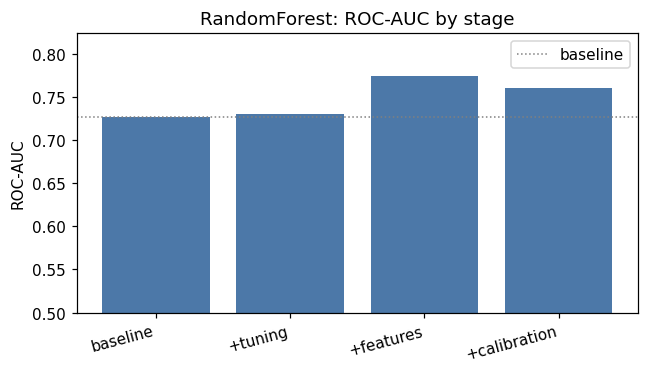

In [17]:
rf_summary = summarize_model("RandomForest")

# Part C: XGBoost

### C.1 Baseline

In [18]:
import xgboost as xgb

xgb_scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_baseline = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=xgb_scale_pos_weight,
    eval_metric="logloss", n_jobs=-1, random_state=42,
)
xgb_baseline.fit(get_fp(meta_train), y_train)
prob = xgb_baseline.predict_proba(get_fp(meta_test))[:, 1]
_ = record("XGBoost", "baseline", y_test, prob, meta_test)

[XGBoost             | baseline      ] ROC-AUC=0.716  PR-AUC=0.715  balanced_acc=0.645 (thr=0.50)  F1=0.636


### C.2 Hyperparameter tuning

In [19]:
xgb_param_dist = {
    "max_depth": randint(3, 9),
    "learning_rate": loguniform(0.01, 0.3),
    "n_estimators": randint(150, 500),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 8),
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=xgb_scale_pos_weight, eval_metric="logloss", n_jobs=-1, random_state=42,
    ),
    xgb_param_dist, n_iter=10, scoring="roc_auc",
    cv=GroupKFold(n_splits=CV_SPLITS), n_jobs=1, random_state=42,
)
xgb_search.fit(get_fp(meta_train), y_train, groups=train_groups)
print(f"Best params: {xgb_search.best_params_}  (CV ROC-AUC={xgb_search.best_score_:.3f})")

xgb_tuned = xgb_search.best_estimator_
prob = xgb_tuned.predict_proba(get_fp(meta_test))[:, 1]
_ = record("XGBoost", "+tuning", y_test, prob, meta_test)
xgb_best_params = xgb_search.best_params_

KeyboardInterrupt: 

### C.3 Feature engineering: fingerprint-only vs. fingerprint + descriptors

In [ ]:
xgb_est_for_features = xgb.XGBClassifier(
    scale_pos_weight=xgb_scale_pos_weight, eval_metric="logloss", n_jobs=-1, random_state=42, **xgb_best_params,
)
cv_fp, _ = cv_roc_auc(xgb_est_for_features, meta_train, feature_fn=get_fp)
cv_fp_desc, _ = cv_roc_auc(xgb_est_for_features, meta_train, feature_fn=fp_desc_features)
print(f"CV ROC-AUC: fp-only={cv_fp:.3f}  fp+descriptors={cv_fp_desc:.3f}")

xgb_feature_kind = "fp_desc" if cv_fp_desc > cv_fp else "fp"
print(f"Winner: {xgb_feature_kind}")

Xtr, xgb_scaler = make_features(xgb_feature_kind, meta_train, meta_train)
Xte, _ = make_features(xgb_feature_kind, meta_train, meta_test, scaler=xgb_scaler)
xgb_final = clone(xgb_est_for_features).fit(Xtr, y_train)
prob = xgb_final.predict_proba(Xte)[:, 1]
_ = record("XGBoost", "+features", y_test, prob, meta_test)

### C.4 Calibration + threshold tuning

In [ ]:
Xfit, xgb_scaler_fit = make_features(xgb_feature_kind, meta_fit, meta_fit)
Xval, _ = make_features(xgb_feature_kind, meta_fit, meta_val, scaler=xgb_scaler_fit)
Xtest_cal, _ = make_features(xgb_feature_kind, meta_fit, meta_test, scaler=xgb_scaler_fit)

xgb_cal_model = clone(xgb_est_for_features).fit(Xfit, y_fit)
val_prob = xgb_cal_model.predict_proba(Xval)[:, 1]
test_prob_raw = xgb_cal_model.predict_proba(Xtest_cal)[:, 1]

test_prob_cal = platt_calibrate(val_prob, y_val, test_prob_raw)
val_prob_cal = platt_calibrate(val_prob, y_val, val_prob)
xgb_best_thr, _ = tune_threshold(y_val, val_prob_cal)

_ = record("XGBoost", "+calibration", y_test, test_prob_cal, meta_test, threshold=xgb_best_thr)

### C.5 Summary — XGBoost

In [ ]:
xgb_summary = summarize_model("XGBoost")

# Part D: TabPFN

### D.1 Baseline

Same config as `eda_and_baselines.ipynb`: PCA to 100 components (fit on the fingerprint matrix,
no descriptor concatenation), subsampled to 3,000 training rows (TabPFN's practical context-size
budget), default ensemble settings.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tabpfn import TabPFNClassifier

TABPFN_MAX_TRAIN = 3000
TABPFN_N_COMPONENTS = 100

def tabpfn_subsample(meta_subset, max_train=TABPFN_MAX_TRAIN, seed=42):
    if len(meta_subset) <= max_train:
        return meta_subset
    y_sub = get_y(meta_subset)
    idx = np.arange(len(meta_subset))
    idx_sub, _ = train_test_split(idx, train_size=max_train, stratify=y_sub, random_state=seed)
    return meta_subset.iloc[idx_sub]

def tabpfn_pca_features(fit_meta, target_meta, n_components, pca=None):
    if pca is None:
        pca = PCA(n_components=n_components, random_state=42).fit(get_fp(fit_meta))
    return pca.transform(get_fp(target_meta)), pca

tabpfn_train_sub = tabpfn_subsample(meta_train)
Xtr, tabpfn_pca = tabpfn_pca_features(tabpfn_train_sub, tabpfn_train_sub, TABPFN_N_COMPONENTS)
Xte, _ = tabpfn_pca_features(tabpfn_train_sub, meta_test, TABPFN_N_COMPONENTS, pca=tabpfn_pca)
print(f"TabPFN training subsample: {len(tabpfn_train_sub)} rows ({get_y(tabpfn_train_sub).mean():.1%} active)")

tabpfn_baseline = TabPFNClassifier(device="auto", random_state=42, ignore_pretraining_limits=True)
tabpfn_baseline.fit(Xtr, get_y(tabpfn_train_sub))
prob = tabpfn_baseline.predict_proba(Xte)[:, 1]
_ = record("TabPFN", "baseline", y_test, prob, meta_test)

### D.2 Hyperparameter tuning: ensemble size + probability balancing

TabPFN has few classical hyperparameters (it's a fixed pretrained transformer, not something
fit from scratch) — the tunable knobs are `n_estimators` (its internal ensemble size) and
`balance_probabilities`. Each config is evaluated once on `meta_val` (not full CV — each
fit+predict call is the expensive part here, not the search overhead, so this keeps the search
cheap).

In [ ]:
tabpfn_configs = [
    {"n_estimators": 4, "balance_probabilities": False},
    {"n_estimators": 8, "balance_probabilities": False},
    {"n_estimators": 8, "balance_probabilities": True},
    {"n_estimators": "auto", "balance_probabilities": False},
]

tabpfn_fit_sub = tabpfn_subsample(meta_fit)
Xfit_tune, tabpfn_pca_tune = tabpfn_pca_features(tabpfn_fit_sub, tabpfn_fit_sub, TABPFN_N_COMPONENTS)
Xval_tune, _ = tabpfn_pca_features(tabpfn_fit_sub, meta_val, TABPFN_N_COMPONENTS, pca=tabpfn_pca_tune)

tabpfn_config_scores = []
for cfg in tabpfn_configs:
    clf = TabPFNClassifier(device="auto", random_state=42, ignore_pretraining_limits=True, **cfg)
    clf.fit(Xfit_tune, get_y(tabpfn_fit_sub))
    val_prob = clf.predict_proba(Xval_tune)[:, 1]
    score = roc_auc_score(y_val, val_prob)
    tabpfn_config_scores.append((cfg, score))
    print(f"{cfg}: val ROC-AUC={score:.3f}")

tabpfn_best_cfg = max(tabpfn_config_scores, key=lambda t: t[1])[0]
print(f"Winner: {tabpfn_best_cfg}")

tabpfn_tuned = TabPFNClassifier(device="auto", random_state=42, ignore_pretraining_limits=True, **tabpfn_best_cfg)
tabpfn_tuned.fit(Xtr, get_y(tabpfn_train_sub))
prob = tabpfn_tuned.predict_proba(Xte)[:, 1]
_ = record("TabPFN", "+tuning", y_test, prob, meta_test)

### D.3 Feature engineering: PCA dimensionality

More components keep more fingerprint information but eat into TabPFN's effective context
budget; fewer components lose information but leave more "room" per compound. Compared the same
way as the hyperparameter search: one fit+predict per option, scored on `meta_val`.

In [ ]:
tabpfn_pca_options = [50, 100, 200]
tabpfn_pca_scores = []
for nc in tabpfn_pca_options:
    Xfit_nc, pca_nc = tabpfn_pca_features(tabpfn_fit_sub, tabpfn_fit_sub, nc)
    Xval_nc, _ = tabpfn_pca_features(tabpfn_fit_sub, meta_val, nc, pca=pca_nc)
    clf = TabPFNClassifier(device="auto", random_state=42, ignore_pretraining_limits=True, **tabpfn_best_cfg)
    clf.fit(Xfit_nc, get_y(tabpfn_fit_sub))
    val_prob = clf.predict_proba(Xval_nc)[:, 1]
    score = roc_auc_score(y_val, val_prob)
    tabpfn_pca_scores.append((nc, score))
    print(f"PCA n_components={nc}: val ROC-AUC={score:.3f}")

tabpfn_best_nc = max(tabpfn_pca_scores, key=lambda t: t[1])[0]
print(f"Winner: PCA n_components={tabpfn_best_nc}")

Xtr_final, tabpfn_pca_final = tabpfn_pca_features(tabpfn_train_sub, tabpfn_train_sub, tabpfn_best_nc)
Xte_final, _ = tabpfn_pca_features(tabpfn_train_sub, meta_test, tabpfn_best_nc, pca=tabpfn_pca_final)
tabpfn_final = TabPFNClassifier(device="auto", random_state=42, ignore_pretraining_limits=True, **tabpfn_best_cfg)
tabpfn_final.fit(Xtr_final, get_y(tabpfn_train_sub))
prob = tabpfn_final.predict_proba(Xte_final)[:, 1]
_ = record("TabPFN", "+features", y_test, prob, meta_test)

### D.4 Calibration + threshold tuning

In [ ]:
Xfit_cal, tabpfn_pca_cal = tabpfn_pca_features(tabpfn_fit_sub, tabpfn_fit_sub, tabpfn_best_nc)
Xval_cal, _ = tabpfn_pca_features(tabpfn_fit_sub, meta_val, tabpfn_best_nc, pca=tabpfn_pca_cal)
Xtest_cal, _ = tabpfn_pca_features(tabpfn_fit_sub, meta_test, tabpfn_best_nc, pca=tabpfn_pca_cal)

tabpfn_cal_model = TabPFNClassifier(device="auto", random_state=42, ignore_pretraining_limits=True, **tabpfn_best_cfg)
tabpfn_cal_model.fit(Xfit_cal, get_y(tabpfn_fit_sub))
val_prob = tabpfn_cal_model.predict_proba(Xval_cal)[:, 1]
test_prob_raw = tabpfn_cal_model.predict_proba(Xtest_cal)[:, 1]

test_prob_cal = platt_calibrate(val_prob, y_val, test_prob_raw)
val_prob_cal = platt_calibrate(val_prob, y_val, val_prob)
tabpfn_best_thr, _ = tune_threshold(y_val, val_prob_cal)

_ = record("TabPFN", "+calibration", y_test, test_prob_cal, meta_test, threshold=tabpfn_best_thr)

### D.5 Summary — TabPFN

In [ ]:
tabpfn_summary = summarize_model("TabPFN")

# Part E: CheMeleon

### E.1 Setup + baseline

Writes `meta_fit`/`meta_val`/`meta_test` to chemprop CSVs (both a plain version and a version
with the 10 physicochemical descriptors as extra columns, for the feature-engineering stage
below), then trains the same baseline config as `eda_and_baselines.ipynb`. Each `chemprop train`/
`predict` call is cached to disk (skipped if its output already exists), so re-running this
notebook after fixing an unrelated bug downstream doesn't redo GPU work that already finished.

In [ ]:
import subprocess

CHEMPROP_DIR_IMP = f"{REPO_ROOT}/notebooks/_chemprop_run_improving"
CHEMPROP_BIN = "/nethome/akarimi/miniconda3/envs/influnc/bin/chemprop"
os.makedirs(CHEMPROP_DIR_IMP, exist_ok=True)
DESC_COLS = list(DESCRIPTOR_FUNCS.keys())

def write_chemprop_csvs(meta_subset, stem):
    base_cols = ["canonical_smiles", "cytotoxic_label"]
    meta_subset[base_cols].to_csv(f"{CHEMPROP_DIR_IMP}/{stem}.csv", index=False)
    desc_raw = get_desc_raw(meta_subset)
    with_desc = meta_subset[base_cols].copy()
    for i, name in enumerate(DESC_COLS):
        with_desc[name] = desc_raw[:, i]
    with_desc.to_csv(f"{CHEMPROP_DIR_IMP}/{stem}_desc.csv", index=False)

for stem, meta_subset in [("train", meta_fit), ("val", meta_val), ("test", meta_test)]:
    write_chemprop_csvs(meta_subset, stem)
print(f"train={len(meta_fit)}  val={len(meta_val)}  test={len(meta_test)}")

def run_chemprop_train(run_name, extra_args=None, descriptors=False):
    ckpt = f"{CHEMPROP_DIR_IMP}/{run_name}/model_0/best.pt"
    if os.path.exists(ckpt):
        print(f"{run_name}: checkpoint already exists, skipping training.")
        return ckpt
    suffix = "_desc" if descriptors else ""
    cmd = [
        CHEMPROP_BIN, "train",
        "-i", f"train{suffix}.csv", f"val{suffix}.csv",
        "-s", "canonical_smiles", "--target-columns", "cytotoxic_label", "--task-type", "classification",
        "--from-foundation", "CHEMELEON",
        "--epochs", "30", "--split-sizes", "0.9", "0.1", "0.0",
        "-o", run_name,
    ]
    if descriptors:
        cmd += ["--descriptors-columns"] + DESC_COLS
    if extra_args:
        cmd += extra_args
    result = subprocess.run(cmd, cwd=CHEMPROP_DIR_IMP, capture_output=True, text=True)
    print(result.stdout[-1500:])
    if result.returncode != 0:
        print(result.stderr[-3000:])
    result.check_returncode()
    return ckpt

def run_chemprop_predict(run_name, split, out_name, descriptors=False):
    out_path = f"{CHEMPROP_DIR_IMP}/{out_name}"
    if not os.path.exists(out_path):
        suffix = "_desc" if descriptors else ""
        cmd = [
            CHEMPROP_BIN, "predict",
            "-i", f"{split}{suffix}.csv", "-s", "canonical_smiles",
            "--model-paths", f"{run_name}/model_0/best.pt",
            "-o", out_name,
        ]
        if descriptors:
            cmd += ["--descriptors-columns"] + DESC_COLS
        result = subprocess.run(cmd, cwd=CHEMPROP_DIR_IMP, capture_output=True, text=True)
        if result.returncode != 0:
            print(result.stdout[-1000:]); print(result.stderr[-2000:])
        result.check_returncode()
    return pd.read_csv(out_path)["cytotoxic_label"].values

run_chemprop_train("chemeleon_baseline")
chem_val_prob = run_chemprop_predict("chemeleon_baseline", "val", "chemeleon_baseline_val_preds.csv")
chem_test_prob = run_chemprop_predict("chemeleon_baseline", "test", "chemeleon_baseline_test_preds.csv")
_ = record("CheMeleon", "baseline", y_test, chem_test_prob, meta_test)

### E.2 Hyperparameter tuning: bigger message-passing network

Trains one alternate config — deeper message passing (`--depth 4` vs. the default 3) and a wider
FFN head (`--ffn-hidden-dim 500` vs. the default) — and keeps whichever of {baseline, bigger}
scores higher on `meta_val`.

In [ ]:
run_chemprop_train("chemeleon_bigger", extra_args=["--depth", "4", "--ffn-hidden-dim", "500"])
bigger_val_prob = run_chemprop_predict("chemeleon_bigger", "val", "chemeleon_bigger_val_preds.csv")
bigger_test_prob = run_chemprop_predict("chemeleon_bigger", "test", "chemeleon_bigger_test_preds.csv")

val_auc_baseline = roc_auc_score(y_val, chem_val_prob)
val_auc_bigger = roc_auc_score(y_val, bigger_val_prob)
print(f"val ROC-AUC: baseline={val_auc_baseline:.3f}  bigger={val_auc_bigger:.3f}")

if val_auc_bigger > val_auc_baseline:
    chem_best_run, chem_best_extra_args, chem_best_desc = "chemeleon_bigger", ["--depth", "4", "--ffn-hidden-dim", "500"], False
    chem_val_prob, chem_test_prob = bigger_val_prob, bigger_test_prob
else:
    chem_best_run, chem_best_extra_args, chem_best_desc = "chemeleon_baseline", None, False
print(f"Winner: {chem_best_run}")

_ = record("CheMeleon", "+tuning", y_test, chem_test_prob, meta_test)

### E.3 Feature engineering: concatenate physicochemical descriptors

`chemprop`'s `--descriptors-columns` concatenates extra per-molecule features onto the learned
graph representation before the FFN head — the GNN analog of the fp+descriptors feature variant
tried for the sklearn models. Trains with the winning hyperparameters from E.2 plus descriptors,
and keeps whichever of {E.2's winner, +descriptors} scores higher on `meta_val`.

In [ ]:
run_chemprop_train("chemeleon_desc", extra_args=chem_best_extra_args, descriptors=True)
desc_val_prob = run_chemprop_predict("chemeleon_desc", "val", "chemeleon_desc_val_preds.csv", descriptors=True)
desc_test_prob = run_chemprop_predict("chemeleon_desc", "test", "chemeleon_desc_test_preds.csv", descriptors=True)

val_auc_prev = roc_auc_score(y_val, chem_val_prob)
val_auc_desc = roc_auc_score(y_val, desc_val_prob)
print(f"val ROC-AUC: {chem_best_run}={val_auc_prev:.3f}  +descriptors={val_auc_desc:.3f}")

if val_auc_desc > val_auc_prev:
    chem_best_run, chem_best_desc = "chemeleon_desc", True
    chem_val_prob, chem_test_prob = desc_val_prob, desc_test_prob
print(f"Winner: {chem_best_run} (descriptors={chem_best_desc})")

_ = record("CheMeleon", "+features", y_test, chem_test_prob, meta_test)

### E.4 Calibration + threshold tuning

Both the val and test predictions from the winning config are already in hand from the stages
above — no extra `chemprop` calls needed, just Platt scaling + threshold search on `meta_val`.

In [ ]:
test_prob_cal = platt_calibrate(chem_val_prob, y_val, chem_test_prob)
val_prob_cal = platt_calibrate(chem_val_prob, y_val, chem_val_prob)
chem_best_thr, _ = tune_threshold(y_val, val_prob_cal)

_ = record("CheMeleon", "+calibration", y_test, test_prob_cal, meta_test, threshold=chem_best_thr)

### E.5 Summary — CheMeleon

In [ ]:
chem_summary = summarize_model("CheMeleon")

# Part F: DeepTox-style DNN

### F.1 Baseline

Same architecture and training budget as `eda_and_baselines.ipynb` (two hidden layers, dropout
0.5, 30 epochs, fp+descriptor features), but using this notebook's shared training loop, which
checkpoints the best validation-ROC-AUC epoch rather than just using the final epoch's weights —
a strictly fair-or-better version of the same baseline.

In [ ]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

class DeepToxDNN(nn.Module):
    def __init__(self, in_dim, hidden_dims=(512, 128), dropout=0.5):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_dnn(Xtr, ytr, Xva, yva, hidden_dims=(512, 128), dropout=0.5, lr=1e-3, weight_decay=1e-5,
              epochs=30, patience=5, batch_size=128, seed=42):
    torch.manual_seed(seed)
    model = DeepToxDNN(in_dim=Xtr.shape[1], hidden_dims=hidden_dims, dropout=dropout).to(device)
    pos_weight = torch.tensor([(ytr == 0).sum() / (ytr == 1).sum()], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    Xt = torch.tensor(Xtr, dtype=torch.float32, device=device)
    yt = torch.tensor(ytr, dtype=torch.float32, device=device)
    Xv = torch.tensor(Xva, dtype=torch.float32, device=device)

    best_val_auc, best_state, epochs_no_improve = -1.0, None, 0
    n = len(Xt)
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i : i + batch_size]
            optimizer.zero_grad()
            loss = criterion(model(Xt[idx]), yt[idx])
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_prob = torch.sigmoid(model(Xv)).cpu().numpy()
        val_auc = roc_auc_score(yva, val_prob)
        if val_auc > best_val_auc:
            best_val_auc, epochs_no_improve = val_auc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model, best_val_auc

def dnn_predict(model, Xarr):
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(Xarr, dtype=torch.float32, device=device))).cpu().numpy()

Xtr_dnn, dnn_scaler = fp_desc_features(meta_train, meta_train)
Xte_dnn, _ = fp_desc_features(meta_train, meta_test, scaler=dnn_scaler)
Xva_dnn_base, _ = fp_desc_features(meta_train, meta_val, scaler=dnn_scaler)

dnn_baseline, _ = train_dnn(
    Xtr_dnn, y_train, Xva_dnn_base, y_val,
    hidden_dims=(512, 128), dropout=0.5, lr=1e-3, weight_decay=1e-5, epochs=30, patience=30,
)
prob = dnn_predict(dnn_baseline, Xte_dnn)
_ = record("DeepTox-style DNN", "baseline", y_test, prob, meta_test)

### F.2 Hyperparameter tuning

A 6-trial random search over architecture width/depth, dropout, learning rate and weight decay,
each trained on `meta_fit` with early stopping on `meta_val` (25-epoch budget, patience 5) to
keep the search itself cheap — the winner is then retrained on the full training set with a
longer budget for the actual "+tuning" evaluation.

In [ ]:
dnn_trial_space = [
    {"hidden_dims": (512, 128), "dropout": 0.5, "lr": 1e-3, "weight_decay": 1e-5},
    {"hidden_dims": (256, 64), "dropout": 0.3, "lr": 1e-3, "weight_decay": 1e-5},
    {"hidden_dims": (512, 256, 64), "dropout": 0.5, "lr": 5e-4, "weight_decay": 1e-4},
    {"hidden_dims": (256, 64), "dropout": 0.5, "lr": 2e-3, "weight_decay": 1e-5},
    {"hidden_dims": (512, 128), "dropout": 0.3, "lr": 5e-4, "weight_decay": 1e-4},
    {"hidden_dims": (128, 64), "dropout": 0.3, "lr": 1e-3, "weight_decay": 1e-6},
]

Xfit_dnn, dnn_scaler_fit = fp_desc_features(meta_fit, meta_fit)
Xval_dnn, _ = fp_desc_features(meta_fit, meta_val, scaler=dnn_scaler_fit)

dnn_trial_scores = []
for cfg in dnn_trial_space:
    _, val_auc = train_dnn(Xfit_dnn, y_fit, Xval_dnn, y_val, epochs=25, patience=5, **cfg)
    dnn_trial_scores.append((cfg, val_auc))
    print(f"{cfg}: val ROC-AUC={val_auc:.3f}")

dnn_best_cfg = max(dnn_trial_scores, key=lambda t: t[1])[0]
print(f"Winner: {dnn_best_cfg}")

dnn_tuned, _ = train_dnn(Xtr_dnn, y_train, Xva_dnn_base, y_val, epochs=40, patience=40, **dnn_best_cfg)
prob = dnn_predict(dnn_tuned, Xte_dnn)
_ = record("DeepTox-style DNN", "+tuning", y_test, prob, meta_test)

### F.3 Feature engineering: + MACCS keys

Adds RDKit's 167-bit MACCS structural keys (a fixed, expert-curated substructure vocabulary,
distinct from Morgan fingerprints' learned circular-neighborhood hashing) alongside fp+descriptors,
compared the same way as elsewhere: trained on `meta_fit`, scored on `meta_val`.

In [ ]:
def get_maccs(meta):
    return np.stack([maccs_cache[s] for s in meta["canonical_smiles"]])

def fp_desc_maccs_features(fit_meta, target_meta, scaler=None):
    if scaler is None:
        scaler = StandardScaler().fit(get_desc_raw(fit_meta))
    desc = scaler.transform(get_desc_raw(target_meta))
    return np.concatenate([get_fp(target_meta), desc, get_maccs(target_meta)], axis=1).astype(np.float32), scaler

Xfit_m, dnn_scaler_m = fp_desc_maccs_features(meta_fit, meta_fit)
Xval_m, _ = fp_desc_maccs_features(meta_fit, meta_val, scaler=dnn_scaler_m)

_, val_auc_fp_desc = train_dnn(Xfit_dnn, y_fit, Xval_dnn, y_val, epochs=25, patience=5, **dnn_best_cfg)
_, val_auc_fp_desc_maccs = train_dnn(Xfit_m, y_fit, Xval_m, y_val, epochs=25, patience=5, **dnn_best_cfg)
print(f"val ROC-AUC: fp+desc={val_auc_fp_desc:.3f}  fp+desc+MACCS={val_auc_fp_desc_maccs:.3f}")

dnn_feature_kind = "fp_desc_maccs" if val_auc_fp_desc_maccs > val_auc_fp_desc else "fp_desc"
print(f"Winner: {dnn_feature_kind}")

if dnn_feature_kind == "fp_desc_maccs":
    Xtr_final, dnn_scaler_final = fp_desc_maccs_features(meta_train, meta_train)
    Xte_final, _ = fp_desc_maccs_features(meta_train, meta_test, scaler=dnn_scaler_final)
    Xva_final = Xva_dnn_base
    _, Xva_final = fp_desc_maccs_features(meta_train, meta_val, scaler=dnn_scaler_final)
else:
    Xtr_final, Xte_final, Xva_final = Xtr_dnn, Xte_dnn, Xva_dnn_base

dnn_final, _ = train_dnn(Xtr_final, y_train, Xva_final, y_val, epochs=40, patience=40, **dnn_best_cfg)
prob = dnn_predict(dnn_final, Xte_final)
_ = record("DeepTox-style DNN", "+features", y_test, prob, meta_test)

### F.4 Calibration + threshold tuning

In [ ]:
feature_fn = fp_desc_maccs_features if dnn_feature_kind == "fp_desc_maccs" else fp_desc_features
Xfit_cal, dnn_scaler_cal = feature_fn(meta_fit, meta_fit)
Xval_cal, _ = feature_fn(meta_fit, meta_val, scaler=dnn_scaler_cal)
Xtest_cal, _ = feature_fn(meta_fit, meta_test, scaler=dnn_scaler_cal)

dnn_cal_model, _ = train_dnn(Xfit_cal, y_fit, Xval_cal, y_val, epochs=40, patience=10, **dnn_best_cfg)
val_prob = dnn_predict(dnn_cal_model, Xval_cal)
test_prob_raw = dnn_predict(dnn_cal_model, Xtest_cal)

test_prob_cal = platt_calibrate(val_prob, y_val, test_prob_raw)
val_prob_cal = platt_calibrate(val_prob, y_val, val_prob)
dnn_best_thr, _ = tune_threshold(y_val, val_prob_cal)

_ = record("DeepTox-style DNN", "+calibration", y_test, test_prob_cal, meta_test, threshold=dnn_best_thr)

### F.5 Summary — DeepTox-style DNN

In [ ]:
dnn_summary = summarize_model("DeepTox-style DNN")

## Final: baseline vs. fully-improved, across all six models

Every model's full stage-by-stage history is in `improve_results`. This compares just the two
endpoints — `baseline` vs. `+calibration` (tuning + features + calibration all applied) — on the
same scaffold-split test set used throughout. Note `balanced_accuracy`/F1 gains partly reflect the
tuned decision threshold (found on `meta_val`) rather than the 0.5 default used at baseline, not
purely better-ranked probabilities — ROC-AUC/PR-AUC are threshold-free and the cleaner signal for
"did the model actually get better."</br>

In [ ]:
final_stage = "+calibration"
baseline_rows = pd.DataFrame([r for r in improve_results if r["stage"] == "baseline"]).set_index("model")
final_rows = pd.DataFrame([r for r in improve_results if r["stage"] == final_stage]).set_index("model")

rollup = baseline_rows[["roc_auc", "pr_auc", "balanced_accuracy", "f1"]].join(
    final_rows[["roc_auc", "pr_auc", "balanced_accuracy", "f1"]], lsuffix="_baseline", rsuffix="_improved",
)
rollup["roc_auc_gain"] = rollup["roc_auc_improved"] - rollup["roc_auc_baseline"]
rollup = rollup.sort_values("roc_auc_gain", ascending=False)
print(rollup.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
model_order = rollup.index.tolist()
x = np.arange(len(model_order))
width = 0.35
ax.bar(x - width / 2, rollup.loc[model_order, "roc_auc_baseline"], width, label="baseline", color="#4C78A8")
ax.bar(x + width / 2, rollup.loc[model_order, "roc_auc_improved"], width, label="improved (+tuning+features+calibration)", color="#54A24B")
ax.axhline(0.5, color="gray", ls=":", lw=1, label="random guessing")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=30, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.4, 1.0)
ax.set_title("Baseline vs. improved, by model (scaffold-split test set)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
full_table = pd.DataFrame(improve_results)
full_table